In [1]:
# %% CELL 1 ─ Imports and configuration
# ---------------------------------------------------------------------------
# Goal: empirically test the Gaussian ("diffusive-style") mixing model of
# Tierney & Ibarra (their Eqs. 5-6), S_mixed = G * S, where G is a Gaussian
# kernel in DEPTH with standard deviation sigma (the "mixing length").
# They tune sigma so pseudoproxy variance matches data variance and get:
#     CO2 = 75 cm, dD = 30 cm, MOT = 25 cm  (Table S1)
#
# Key idea of this test: a Gaussian kernel has a precise, falsifiable signature.
# Where folded blue ice juxtaposes two ice packages of different age, the
# primary signal is (locally) a STEP. Convolving a step with a Gaussian gives
# an error function (erf) whose width is exactly sigma. The Hudak CFA data are
# sampled every 5 cm, so they can resolve the width of these contacts directly.
# If sigma were 30 cm, every dD contact would be smeared over ~0.8 m (10-90%).
# ---------------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.special import erf
from scipy.optimize import least_squares, curve_fit
from scipy.signal import find_peaks, fftconvolve
from scipy.stats import chi2
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

DATA_DIR = Path.home() / 'Downloads'
FILES = {
    'ALHIC2201': 'ALHIC2201_CFA_(water-isotopes-CH4-dust).csv',
    'ALHIC2302': 'ALHIC2302_CFA_(water-isotopes-CH4-dust).csv',
}
DZ = 0.05   # CFA data are reported on a 5 cm depth grid (m)

# Mixing lengths Tierney & Ibarra inferred (m). CH4 is our gas analogue for CO2.
TIERNEY_SIGMA = {'dD': 0.30, 'CH4': 0.75, 'MOT': 0.25}

pd.set_option('display.width', 200)


In [2]:
# %% CELL 2 ─ Load and harmonise the two CFA files
# ---------------------------------------------------------------------------
# The two files have different column headers (e.g. 'd18O' vs 'd18O (per mille)',
# an empty unnamed column in 2302, a 'replicate' column in 2201).
#  * ALHIC2201 'replicate' = 2 is NOT a duplicate measurement of the same ice:
#    it mostly continues the core from 64.95-69 m (only 3 depths fall inside the
#    replicate-1 range, and none coincide exactly). So we merge the two.
#  * ALHIC2302 has four duplicate rows at 16.55 m; we average duplicates.
#  * 'age (kyr)' is only given at discrete tie-point intervals (69 rows in
#    2201, 57 in 2302). These ages jump non-monotonically with depth (folded
#    ice), which is exactly why we expect sharp contacts.
# ---------------------------------------------------------------------------
def load_cfa(path):
    df = pd.read_csv(path)
    df = df.loc[:, ~df.columns.str.startswith('Unnamed')]      # drop empty column
    rename = {}
    for c in df.columns:
        key = c.lower()
        for prefix, new in [('depth', 'depth'), ('d18o', 'd18O'), ('dd', 'dD'),
                            ('dxs', 'dxs'), ('dust', 'dust'), ('ch4', 'CH4'),
                            ('age', 'age')]:
            if key.startswith(prefix):
                rename[c] = new
                break
    df = df.rename(columns=rename).drop(columns=['replicate'], errors='ignore')
    # average any rows sharing a depth, then sort
    df = (df.groupby('depth', as_index=False).mean(numeric_only=True)
            .sort_values('depth').reset_index(drop=True))
    # dust is log-normally distributed (spikes over 2 orders of magnitude);
    # work in log10 so a step is a step and not dominated by spikes
    df['logdust'] = np.log10(df['dust'])
    return df

cores = {name: load_cfa(DATA_DIR / fn) for name, fn in FILES.items()}
for name, df in cores.items():
    print(f"{name}: {len(df)} depths, {df.depth.min():.2f}-{df.depth.max():.2f} m, "
          f"age ties {df.age.min():.0f}-{df.age.max():.0f} ka")
    print(df[['dD', 'CH4', 'logdust']].notna().sum().to_dict())


ALHIC2201: 1246 depths, 0.00-69.00 m, age ties 149-1054 ka
{'dD': 1197, 'CH4': 1095, 'logdust': 1159}
ALHIC2302: 801 depths, 0.00-46.35 m, age ties 270-568 ka
{'dD': 801, 'CH4': 801, 'logdust': 801}


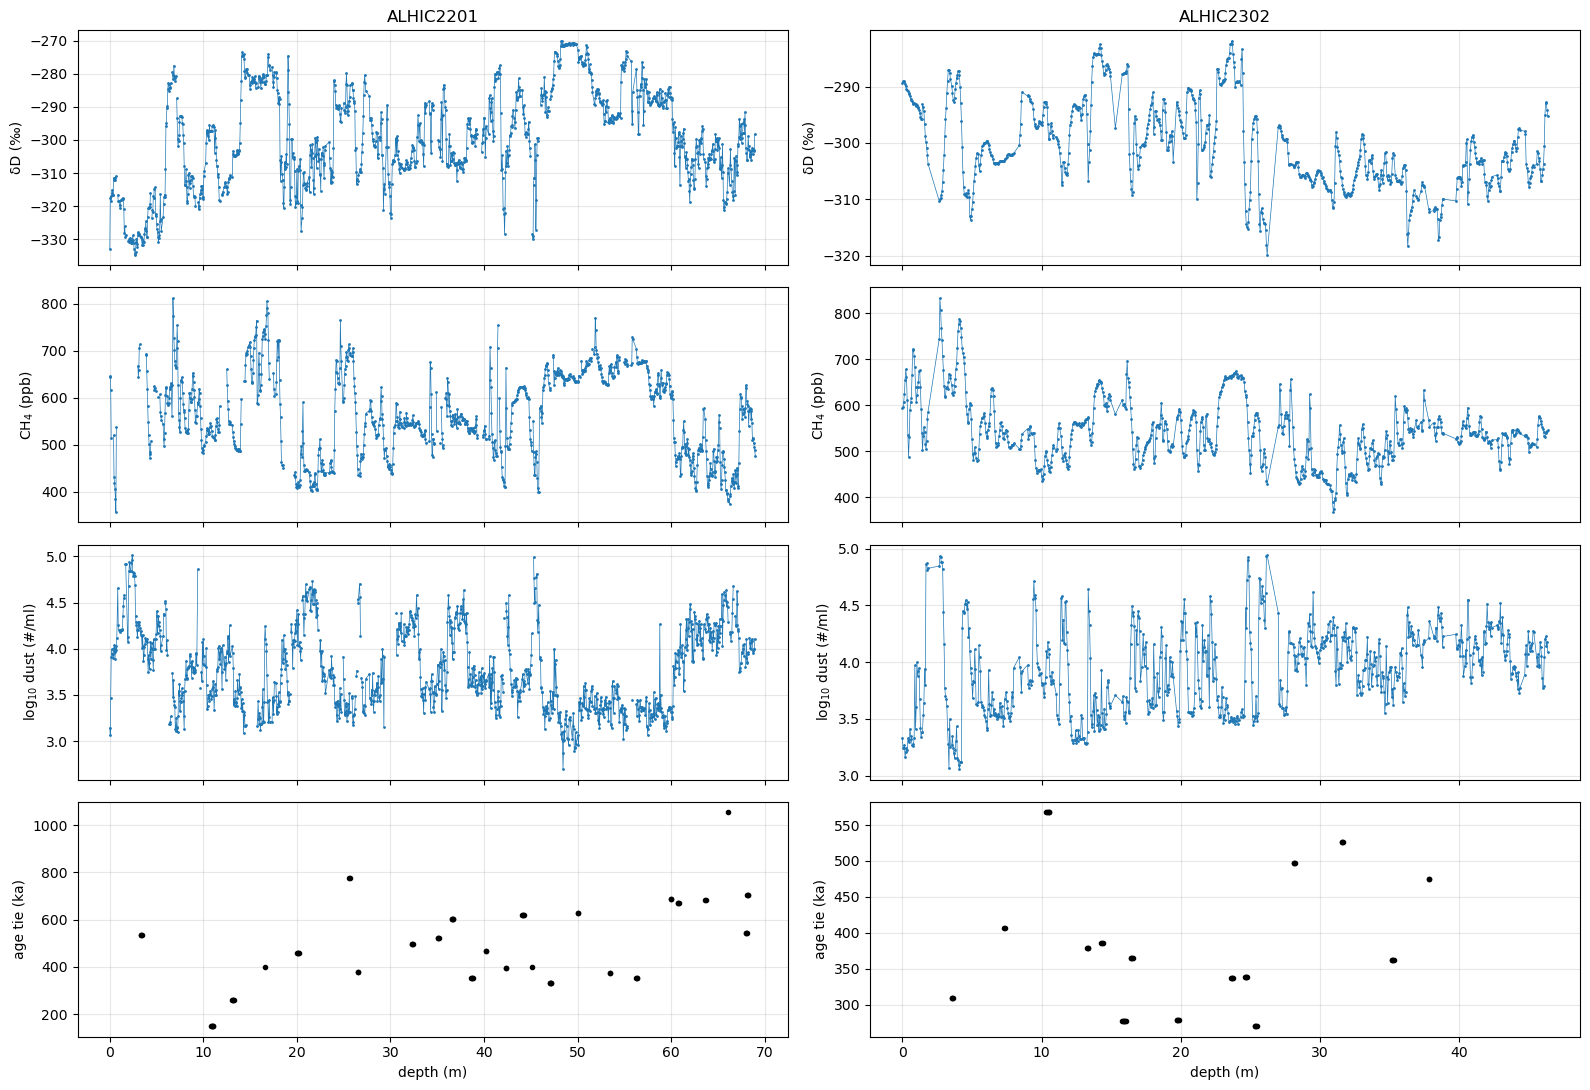

In [3]:
# %% CELL 3 ─ Overview plot
# ---------------------------------------------------------------------------
# Just look at the data. Note the many abrupt, near-vertical steps in dD and
# CH4, and the scattered, non-monotonic age tie points (bottom row).
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(4, 2, figsize=(16, 11), sharex='col')
for j, (name, df) in enumerate(cores.items()):
    for i, (var, lab) in enumerate([('dD', 'δD (‰)'), ('CH4', 'CH$_4$ (ppb)'),
                                    ('logdust', 'log$_{10}$ dust (#/ml)'),
                                    ('age', 'age tie (ka)')]):
        a = ax[i, j]
        if var == 'age':
            a.plot(df.depth, df.age, 'o', ms=3, color='k')
        else:
            a.plot(df.depth, df[var], '.-', ms=2, lw=0.5)
        a.set_ylabel(lab); a.grid(alpha=0.3)
    ax[0, j].set_title(name)
    ax[-1, j].set_xlabel('depth (m)')
plt.tight_layout(); plt.show()


In [4]:
# %% CELL 4 ─ The Tierney & Ibarra mixing operator + regular-grid helper
# ---------------------------------------------------------------------------
# segments(): the CFA record has gaps (breaks / missing sections). We never want
# to interpolate or convolve across a gap, so we split each variable into
# continuous segments (gaps > max_gap end a segment), and put each segment on an
# exact 5 cm grid (tiny single-sample holes get linearly filled).
#
# gaussian_mix(): Eq. 5-6 of Tierney & Ibarra. Convolution with a normalised
# Gaussian in depth. We use "normalised convolution" (divide by the convolved
# ones-vector) so segment edges are not biased toward zero.
# ---------------------------------------------------------------------------
def segments(df, var, max_gap=0.15, min_pts=8):
    d = df[['depth', var]].dropna()
    z_all, y_all = d.depth.values, d[var].values
    breaks = np.where(np.diff(z_all) > max_gap + 1e-9)[0] + 1
    out = []
    for idx in np.split(np.arange(len(z_all)), breaks):
        if len(idx) < min_pts:
            continue
        z, y = z_all[idx], y_all[idx]
        zg = np.round(np.arange(z[0], z[-1] + DZ / 2, DZ), 3)
        out.append((zg, np.interp(zg, z, y)))
    return out

def gaussian_mix(z, y, sigma):
    """Tierney & Ibarra Eq. 5-6: convolve y(z) with a Gaussian of s.d. sigma (m)."""
    if sigma <= 0:
        return y.copy()
    dz = np.median(np.diff(z))
    half = int(np.ceil(4 * sigma / dz))                 # kernel out to ±4 sigma
    k = np.exp(-0.5 * (np.arange(-half, half + 1) * dz / sigma) ** 2)
    return fftconvolve(y, k, 'same') / fftconvolve(np.ones_like(y), k, 'same')


In [5]:
# %% CELL 5 ─ The step-response model and fitter
# ---------------------------------------------------------------------------
# If the true (pre-mixing) profile is a step of size b at depth z0, then the
# Gaussian-mixed profile is exactly:
#     y(z) = a + c (z - z0) + (b/2) [1 + erf((z - z0) / (sqrt(2) sigma))]
# (c = small linear background so real within-package trends don't bias sigma)
#
# Important: the measured width is an UPPER bound on in-ice mixing because it
# also contains (i) 5 cm sample averaging (boxcar -> sigma ≈ 1.4 cm) and (ii)
# CFA melt-line dispersion. Widths add in quadrature:
#     sigma_obs^2 = sigma_ice^2 + sigma_CFA^2 + sigma_sampling^2
#
# fit_step(): least squares, sigma free (or fixed, for profile likelihood).
# profile_ci(): for a grid of fixed sigma, refit the other 4 parameters and
# compute Δχ² = ΔRSS / s², giving a 95% CI on sigma (Δχ² < 3.84) and the
# direct likelihood-ratio statistic against Tierney's specific sigma values.
# Note: with sigma fixed large, erf + slope c can partly mimic a sharp step,
# which makes this test LENIENT toward large sigma (conservative for us).
# ---------------------------------------------------------------------------
def erf_step(p, z):
    a, b, z0, s, c = p
    return a + c * (z - z0) + 0.5 * b * (1 + erf((z - z0) / (np.sqrt(2) * s)))

def fit_step(z, y, z0_guess, sigma_fixed=None):
    a0 = np.mean(y[z < z0_guess][-4:])
    b0 = np.mean(y[z > z0_guess][:4]) - a0
    if sigma_fixed is None:
        p0 = [a0, b0, z0_guess, 0.05, 0.0]
        lb = [-np.inf, -np.inf, z0_guess - 0.15, 0.003, -np.inf]
        ub = [ np.inf,  np.inf, z0_guess + 0.15, 3.0,    np.inf]
        r = least_squares(lambda p: erf_step(p, z) - y, p0, bounds=(lb, ub))
        return r.x, np.sum(r.fun ** 2)
    f = lambda q: erf_step([q[0], q[1], q[2], sigma_fixed, q[3]], z) - y
    r = least_squares(f, [a0, b0, z0_guess, 0.0],
                      bounds=([-np.inf, -np.inf, z0_guess - 0.3, -np.inf],
                              [ np.inf,  np.inf, z0_guess + 0.3,  np.inf]))
    return np.r_[r.x[:3], sigma_fixed, r.x[3]], np.sum(r.fun ** 2)

SIGMA_GRID = np.r_[0.003, np.arange(0.01, 1.01, 0.01)]

def profile_ci(z, y, z0, rss_free, n_par=5):
    s2 = rss_free / (len(z) - n_par)                    # residual variance
    prof = np.array([fit_step(z, y, z0, sigma_fixed=g)[1] for g in SIGMA_GRID])
    dchi = (prof - prof.min()) / s2
    inside = SIGMA_GRID[dchi < chi2.ppf(0.95, 1)]
    return inside.min(), inside.max(), dchi, np.sqrt(s2)


In [6]:
# %% CELL 6 ─ Validate the fitter on synthetic steps BEFORE touching real data
# ---------------------------------------------------------------------------
# Build a sharp step on a 1 mm grid, apply Tierney mixing with known sigma,
# average into 5 cm bins (like CFA sampling), add noise (SNR = 20), and fit.
# This tells us what sigma range the method can actually resolve.
# ---------------------------------------------------------------------------
rng = np.random.default_rng(0)
z_fine = np.arange(-3, 3, 0.001)
step_true = np.where(z_fine > 0.013, 20.0, 0.0)          # off-grid step location
z_obs = np.round(np.arange(-0.6, 0.6, DZ), 3)
rows = []
for s_true in [0.0, 0.02, 0.05, 0.10, 0.20, 0.30, 0.50]:
    mixed = gaussian_mix(z_fine, step_true, s_true)
    binned = np.array([mixed[(z_fine >= q - DZ/2) & (z_fine < q + DZ/2)].mean() for q in z_obs])
    fits = [fit_step(z_obs, binned + rng.normal(0, 1, len(z_obs)), 0.0)[0][3] for _ in range(100)]
    rows.append(dict(sigma_true=s_true, median_fit=np.median(fits),
                     p05=np.percentile(fits, 5), p95=np.percentile(fits, 95)))
print(pd.DataFrame(rows).round(3))
# EXPECT: good recovery for ~0.02-0.20 m; floor ≈ 0.014 m (5 cm boxcar);
# for sigma ≥ 0.3 m a ±0.6 m window cannot pin sigma down (erf ≈ linear ramp).
# That's fine for our purpose: we are testing whether the data are much SHARPER
# than 0.3 m, which is detectable with high confidence (see Cell 8 Δχ²).


   sigma_true  median_fit    p05    p95
0        0.00       0.010  0.003  0.025
1        0.02       0.024  0.003  0.032
2        0.05       0.051  0.040  0.069
3        0.10       0.103  0.075  0.125
4        0.20       0.204  0.123  0.701
5        0.30       0.266  0.047  1.906
6        0.50       0.200  0.003  2.654


In [7]:
# %% CELL 7 ─ Detect contacts in the real CFA data and fit each one
# ---------------------------------------------------------------------------
# detect_steps(): simple, transparent change-point finder. For each point,
# score = mean(next k samples) - mean(previous k samples) (k=4 → 20 cm windows).
# Peaks in |score| exceeding nsig × (robust point-to-point noise) and separated
# by ≥ min_sep are candidate contacts. The step location is between samples.
#
# analyse(): around each contact, take a window of ±0.6 m, truncated halfway to
# neighbouring contacts so two steps are never fit as one, then fit + profile.
#
# QC: drop fits where (i) |amplitude| exceeds the whole record's range (the
# erf degenerated into a long ramp), (ii) the 95% CI hits the 1 m grid edge
# (unconstrained), or (iii) amplitude/noise < 4 (not really a step).
# ---------------------------------------------------------------------------
def detect_steps(zg, yg, k=4, min_sep=0.4, nsig=6):
    n = len(yg)
    score = np.full(n, np.nan)
    for i in range(k, n - k + 1):
        score[i] = np.mean(yg[i:i + k]) - np.mean(yg[i - k:i])
    d = np.diff(yg)
    noise = 1.4826 * np.median(np.abs(d - np.median(d))) / np.sqrt(2)   # robust MAD
    pk, _ = find_peaks(np.nan_to_num(np.abs(score)), height=nsig * noise,
                       distance=int(min_sep / DZ))
    return [(zg[i] - DZ / 2, score[i]) for i in pk]

def analyse(core, var, half=0.6, seg_fn=segments):
    rows = []
    for zg, yg in seg_fn(cores[core], var):
        steps = detect_steps(zg, yg)
        zs = [s[0] for s in steps]
        for j, (z0, _) in enumerate(steps):
            lo = max(z0 - half, (zs[j-1] + z0) / 2 if j > 0 else -np.inf)
            hi = min(z0 + half, (zs[j+1] + z0) / 2 if j < len(zs) - 1 else np.inf)
            m = (zg >= lo) & (zg <= hi)
            z, y = zg[m], yg[m]
            if (z < z0).sum() < 3 or (z > z0).sum() < 3:
                continue
            p, rss = fit_step(z, y, z0)
            lo95, hi95, dchi, noise = profile_ci(z, y, z0, rss)
            rows.append(dict(core=core, var=var, z0=p[2], amp=p[1], sigma=p[3], c=p[4],
                             lo95=lo95, hi95=hi95, n=len(z), noise=noise,
                             dchi_30cm=np.interp(0.30, SIGMA_GRID, dchi),
                             dchi_75cm=np.interp(0.75, SIGMA_GRID, dchi)))
    return pd.DataFrame(rows)

VARS = ['dD', 'CH4', 'logdust']
R = pd.concat([analyse(c, v) for c in cores for v in VARS], ignore_index=True)
record_range = R.apply(lambda r: np.ptp(cores[r.core][r['var']].dropna()), axis=1)
R['qc'] = (R.amp.abs() < record_range) & (R.hi95 < 1.0) & (R.amp.abs() / R.noise > 4)
Q = R[R.qc].copy()
print(R.groupby(['core', 'var']).agg(n_detected=('qc', 'size'), n_pass_qc=('qc', 'sum')))
print('\nFitted contact width sigma (m), QC-passed:')
print(Q.groupby('var').sigma.describe(percentiles=[.25, .5, .75, .9]).round(3))


                   n_detected  n_pass_qc
core      var                           
ALHIC2201 CH4              36         30
          dD               37         26
          logdust          10          7
ALHIC2302 CH4              31         24
          dD               36         28
          logdust          21         14

Fitted contact width sigma (m), QC-passed:
         count   mean    std    min    25%    50%    75%    90%    max
var                                                                   
CH4       54.0  0.067  0.045  0.003  0.036  0.052  0.095  0.122  0.190
dD        54.0  0.054  0.041  0.003  0.023  0.043  0.086  0.113  0.145
logdust   21.0  0.046  0.050  0.003  0.014  0.030  0.054  0.070  0.190


         reject σ=0.10 m  reject σ=0.15 m  reject σ=0.30 m  reject σ=0.75 m
var                                                                        
CH4                 0.57             0.69             0.96              1.0
dD                  0.57             0.70             0.94              1.0
logdust             0.67             0.76             0.90              1.0

Median Δχ² vs σ = 0.30 m: {'CH4': 17.2, 'dD': 18.3, 'logdust': 16.6}
Median Δχ² vs σ = 0.75 m: {'CH4': 21.4, 'dD': 21.2, 'logdust': 20.8}


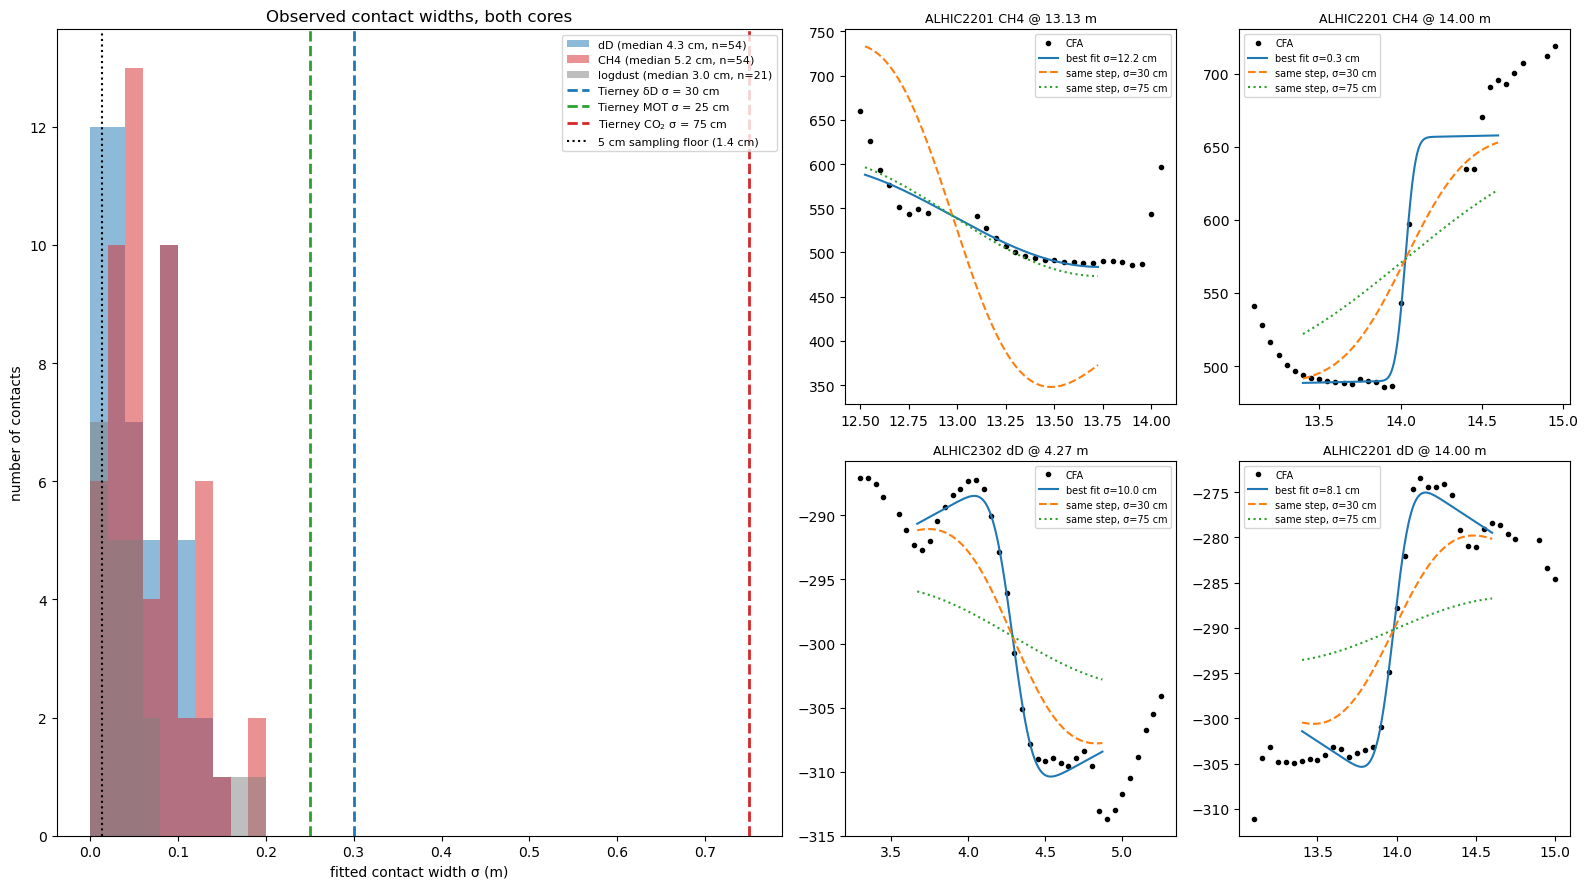

In [8]:
# %% CELL 8 ─ Headline test: are the contacts compatible with Tierney's sigma?
# ---------------------------------------------------------------------------
# For each test sigma, the fraction of contacts whose 95% CI upper bound lies
# BELOW it, i.e. contacts that individually reject that mixing length.
# Also Δχ² at Tierney's values: > 3.84 rejects at 95%, > 6.63 at 99%.
# ---------------------------------------------------------------------------
test_sigmas = [0.10, 0.15, 0.30, 0.75]
summary = pd.DataFrame({f'reject σ={s:.2f} m': Q.groupby('var').hi95.apply(lambda h: (h < s).mean())
                        for s in test_sigmas}).round(2)
print(summary)
print('\nMedian Δχ² vs σ = 0.30 m:', Q.groupby('var').dchi_30cm.median().round(1).to_dict())
print('Median Δχ² vs σ = 0.75 m:', Q.groupby('var').dchi_75cm.median().round(1).to_dict())

# Figure: (left) distribution of widths vs Tierney's values;
#         (right) example contacts: best fit vs the SAME step mixed at 30 / 75 cm
fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(2, 4)
ax0 = fig.add_subplot(gs[:, :2])
bins = np.arange(0, 0.42, 0.02)
for var, col in zip(VARS, ['C0', 'C3', 'C7']):
    ax0.hist(Q[Q['var'] == var].sigma, bins=bins, alpha=0.5, color=col,
             label=f"{var} (median {Q[Q['var']==var].sigma.median()*100:.1f} cm, n={(Q['var']==var).sum()})")
ax0.axvline(0.30, color='C0', ls='--', lw=2, label='Tierney δD σ = 30 cm')
ax0.axvline(0.25, color='C2', ls='--', lw=2, label='Tierney MOT σ = 25 cm')
ax0.axvline(0.75, color='C3', ls='--', lw=2, label='Tierney CO$_2$ σ = 75 cm')
ax0.axvline(0.014, color='k', ls=':', label='5 cm sampling floor (1.4 cm)')
ax0.set_xlabel('fitted contact width σ (m)'); ax0.set_ylabel('number of contacts')
ax0.legend(fontsize=8); ax0.set_title('Observed contact widths, both cores')

# pick the 4 highest-SNR QC'd dD and CH4 contacts that are clean steps
# (background slope over the ±0.6 m window smaller than the step itself)
ex = (Q[Q['var'].isin(['dD', 'CH4']) & (Q.c.abs() * 1.2 < 0.5 * Q.amp.abs())]
      .assign(snr=lambda d: d.amp.abs() / d.noise)
      .sort_values('snr', ascending=False).groupby('var').head(2))
for k, (_, r) in enumerate(ex.iterrows()):
    a = fig.add_subplot(gs[k // 2, 2 + k % 2])
    df = cores[r.core]
    m = (df.depth > r.z0 - 1.0) & (df.depth < r.z0 + 1.0)
    a.plot(df.depth[m], df[r['var']][m], 'ko', ms=3, label='CFA')
    zz = np.linspace(r.z0 - 0.6, r.z0 + 0.6, 400)
    zw = df.depth[(df.depth > r.z0 - 0.6) & (df.depth < r.z0 + 0.6)].values
    yw = df[r['var']][(df.depth > r.z0 - 0.6) & (df.depth < r.z0 + 0.6)].values
    ok = np.isfinite(yw)
    # best fit, then the SAME step (same a, b, z0, c) mixed with Tierney's σ:
    # i.e. what the model predicts this contact should look like
    p_best, _ = fit_step(zw[ok], yw[ok], r.z0)
    for s, ls, lab in [(p_best[3], '-', f'best fit σ={r.sigma*100:.1f} cm'),
                       (0.30, '--', 'same step, σ=30 cm'), (0.75, ':', 'same step, σ=75 cm')]:
        a.plot(zz, erf_step(np.r_[p_best[:3], s, p_best[4]], zz), ls, lw=1.5, label=lab)
    a.set_title(f"{r.core} {r['var']} @ {r.z0:.2f} m", fontsize=9)
    a.legend(fontsize=7)
plt.tight_layout(); plt.show()


In [9]:
# %% CELL 9 ─ Selection-bias check: would we even SEE Tierney mixing?  (~3-4 min)
# ---------------------------------------------------------------------------
# Concern: a step detector might preferentially find sharp steps, so narrow
# widths could be an artefact. Test: apply Tierney mixing (σ_mix) to the REAL
# data, then run the identical detect → fit → QC pipeline. If the pipeline is
# unbiased, it should still find contacts and report σ ≈ sqrt(σ_obs² + σ_mix²).
# This is effectively the model's predicted observation for these cores.
# ---------------------------------------------------------------------------
def mixed_segments(sigma_mix):
    return lambda df, var: [(z, gaussian_mix(z, y, sigma_mix)) for z, y in segments(df, var)]

rows = []
for s_mix in [0.0, 0.05, 0.15, 0.30, 0.75]:
    for var in ['dD', 'CH4']:
        r = pd.concat([analyse(c, var, seg_fn=mixed_segments(s_mix)) for c in cores])
        rng_ = r.apply(lambda q: np.ptp(cores[q.core][q['var']].dropna()), axis=1)
        r = r[(r.amp.abs() < rng_) & (r.hi95 < 1.0) & (r.amp.abs() / r.noise > 4)]
        rows.append(dict(sigma_mix=s_mix, var=var, n_contacts=len(r),
                         median_sigma_fit=r.sigma.median(),
                         expected=np.sqrt(Q[Q['var']==var].sigma.median()**2 + s_mix**2)))
print(pd.DataFrame(rows).round(3))
# EXPECT: median_sigma_fit tracks 'expected' up to ~0.3 m and n_contacts drops
# as σ_mix grows. Real data sit on the σ_mix = 0 row, not the 0.30 row.


   sigma_mix  var  n_contacts  median_sigma_fit  expected
0       0.00   dD          54             0.043     0.043
1       0.00  CH4          54             0.052     0.052
2       0.05   dD          75             0.074     0.066
3       0.05  CH4          69             0.072     0.072
4       0.15   dD          73             0.152     0.156
5       0.15  CH4          82             0.148     0.159
6       0.30   dD          53             0.335     0.303
7       0.30  CH4          43             0.353     0.304
8       0.75   dD          15             0.384     0.751
9       0.75  CH4          12             0.383     0.752


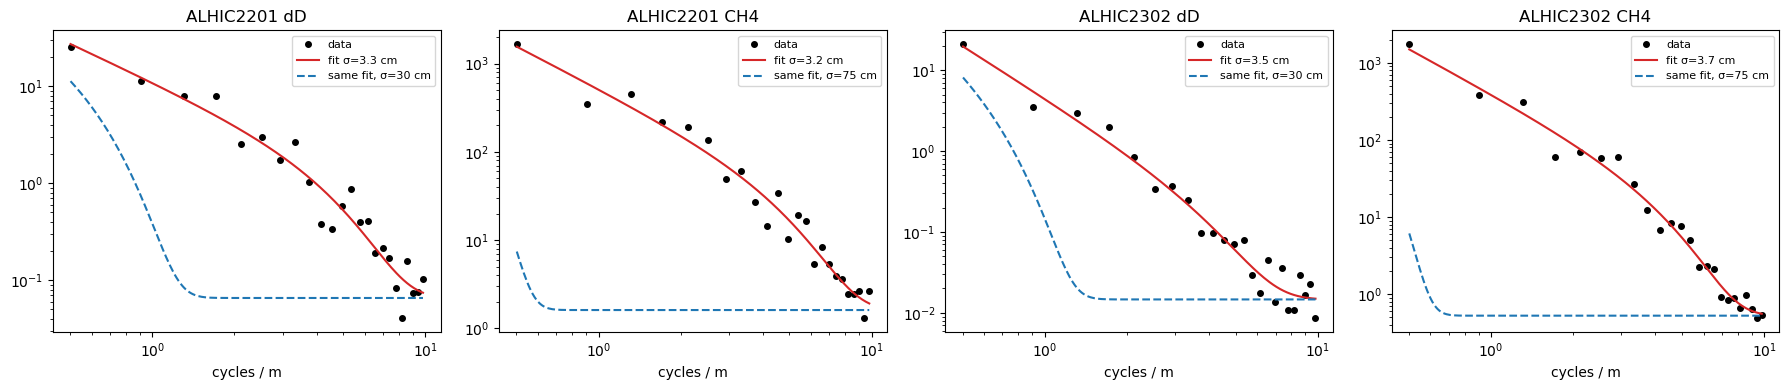

        core  var  n_segments  sigma  sigma_se   beta
0  ALHIC2201   dD           7  0.033     0.007  1.305
1  ALHIC2201  CH4           7  0.032     0.006  1.588
2  ALHIC2302   dD           5  0.035     0.008  2.129
3  ALHIC2302  CH4           5  0.037     0.004  1.919


In [10]:
# %% CELL 10 ─ Independent estimate: spectral diffusion length (no step picking)
# ---------------------------------------------------------------------------
# Gaussian mixing multiplies the power spectrum by exp(-(2π f σ)²) (this is
# the approach of Shaw et al. 2024, which Tierney & Ibarra cite for EDC's
# 31 cm). Fit mean periodogram of continuous segments (≥3 m, linearly
# detrended, Hann-tapered) with
#     P(f) = A f^-β exp(-(2π f σ)²) + N     (N = white measurement noise)
# NOTE: this σ also includes CFA dispersion, so it is again an upper bound.
# With σ = 0.30 m, power at 1 cycle/m would be suppressed ×30 and at
# 2 cycles/m ×10⁶, so the spectrum would hit the noise floor almost immediately.
# ---------------------------------------------------------------------------
def mean_psd(core, var, min_len=3.0, fbins=np.linspace(0.3, 10, 25)):
    spectra = []
    for z, y in segments(cores[core], var):
        if z[-1] - z[0] < min_len:
            continue
        y = y - np.polyval(np.polyfit(z, y, 1), z)
        w = np.hanning(len(y))
        F = np.fft.rfft(y * w)
        f = np.fft.rfftfreq(len(y), DZ)
        spectra.append((f[1:], np.abs(F[1:]) ** 2 * DZ / np.sum(w ** 2)))
    fc, Pc = [], []
    for lo, hi in zip(fbins[:-1], fbins[1:]):           # bin-average across segments
        v = np.concatenate([p[(f >= lo) & (f < hi)] for f, p in spectra])
        if len(v):
            fc.append(0.5 * (lo + hi)); Pc.append(v.mean())
    return np.array(fc), np.array(Pc), len(spectra)

def log_psd_model(f, logA, beta, sigma, logN):
    return np.log(10**logA * f**-beta * np.exp(-(2*np.pi*f*sigma)**2) + 10**logN)

fig, axs = plt.subplots(1, 4, figsize=(18, 4))
spec_rows = []
for k, (core, var) in enumerate([(c, v) for c in cores for v in ['dD', 'CH4']]):
    f, P, nseg = mean_psd(core, var)
    p, cov = curve_fit(log_psd_model, f, np.log(P), p0=[0, 2, 0.03, -3],
                       bounds=([-10, 0, 0, -10], [10, 4, 1, 5]))
    spec_rows.append(dict(core=core, var=var, n_segments=nseg, sigma=p[2],
                          sigma_se=np.sqrt(cov[2, 2]), beta=p[1]))
    a = axs[k]
    a.loglog(f, P, 'ko', ms=4, label='data')
    ff = np.logspace(np.log10(f[0]), np.log10(f[-1]), 200)
    a.loglog(ff, np.exp(log_psd_model(ff, *p)), 'C3', label=f'fit σ={p[2]*100:.1f} cm')
    # what the spectrum would look like with Tierney's σ (same A, β, N)
    s_t = TIERNEY_SIGMA[var]
    a.loglog(ff, np.exp(log_psd_model(ff, p[0], p[1], s_t, p[3])), 'C0--',
             label=f'same fit, σ={s_t*100:.0f} cm')
    a.set_title(f'{core} {var}'); a.set_xlabel('cycles / m'); a.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(pd.DataFrame(spec_rows).round(3))
